In [1]:
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
import torch

D:\Projects\GitRepositories\TheAWOLthing\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from transformers import AutoTokenizer, AutoConfig, AutoModelForQuestionAnswering, pipeline

model_name = "Goader/liberta-large"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)

# If the checkpoint has no QA head, create one and ignore size mismatches
model = AutoModelForQuestionAnswering.from_pretrained(
    model_name,
    config=config,
    trust_remote_code=True,
    ignore_mismatched_sizes=True
)

qa_model = pipeline("question-answering", model=model.to("cuda"), tokenizer=tokenizer)
out = qa_model(question="Як називається суд?", context=context)
print(out)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
D:\Projects\GitRepositories\TheAWOLthing\.venv\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\holys\.cache\huggingface\hub\models--Goader--liberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see t

In [2]:
import torch

ModuleNotFoundError: No module named 'torch'

In [4]:
import os
import re
import pandas as pd
from bs4 import BeautifulSoup
from tqdm import tqdm

# pip install transformers scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

# ------------ Model (QA-finetuned, multilingual) ------------
MODEL_ID = "deepset/xlm-roberta-large-squad2"  # strong baseline
device = 0 if torch.cuda.is_available() else -1

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_ID)
qa_model = pipeline("question-answering", model=model.to("cuda" if device==0 else "cpu"),
                    tokenizer=tokenizer, device=device, handle_impossible_answer=True)

# ------------ Config ------------
html_dir = r"D:\Projects\GitRepositories\TheAWOLthing\AWOL_Research\data\awol_court\data\awol_adm\awol_adm"
questions = [
    "Якого дня, місяця та року відбувся злочин?",
    "Яка військова частина розглядається у справі?",
    "Яка посада військовослужбовця?",
    "Яке звання військовослужбовця?",
    "Як довго тривав злочин?",
    "Скільки гривень штрафу накладено?",
]
max_docs = 50      # limit for testing
top_k_passages = 5
min_answer_score = 0.15  # threshold to filter junk answers

# ------------ Helpers ------------
def split_into_passages(text: str):
    # Prefer paragraphs; if HTML is flat, fall back to sentence-ish chunks
    paras = [p.strip() for p in re.split(r"\n{2,}", text) if p.strip()]
    if not paras:
        # split after periods/semicolons if paragraphs are absent
        paras = [seg.strip() for seg in re.split(r"(?<=[\.\!\?;])\s+", text) if seg.strip()]
    # Merge very short fragments to reduce noise
    merged = []
    buf = []
    for seg in paras:
        buf.append(seg)
        if sum(len(s) for s in buf) > 400:  # ~characters
            merged.append(" ".join(buf))
            buf = []
    if buf:
        merged.append(" ".join(buf))
    return merged

def rank_passages(question: str, passages: list[str], k: int):
    if not passages:
        return []
    vect = TfidfVectorizer(ngram_range=(1,2), min_df=1, max_df=0.9)
    X = vect.fit_transform(passages + [question])
    q_vec = X[-1]
    P = X[:-1]
    sims = cosine_similarity(P, q_vec)
    idx = sims.ravel().argsort()[::-1][:k]
    return [passages[i] for i in idx]

def ask_best(question: str, passages: list[str]):
    best = {"answer": None, "score": -1.0, "context_used": None}
    for ctx in passages:
        try:
            out = qa_model(question=question, context=ctx)
            if out and out.get("score", -1) > best["score"]:
                best = {"answer": out.get("answer"),
                        "score": float(out.get("score", -1)),
                        "context_used": ctx}
        except Exception:
            continue
    # apply a small score floor
    if best["score"] < min_answer_score:
        best["answer"] = None
    return best

# ------------ Main loop ------------
results = []
files = [f for f in os.listdir(html_dir) if f.lower().endswith(".html")]

for filename in tqdm(files[:max_docs], desc="Processing docs"):
    filepath = os.path.join(html_dir, filename)
    with open(filepath, encoding="utf-8") as f:
        soup = BeautifulSoup(f, "html.parser")
        raw = soup.get_text(separator=" ", strip=True)

    if not raw or len(raw) < 20:
        for q in questions:
            results.append({"filename": filename, "question": q,
                            "answer": None, "score": None, "note": "empty_or_short"})
        continue

    passages = split_into_passages(raw)

    for q in questions:
        top_passages = rank_passages(q, passages, top_k_passages)
        ans = ask_best(q, top_passages)
        results.append({
            "filename": filename,
            "question": q,
            "answer": ans["answer"],
            "score": ans["score"],
            # Optionally keep the passage used for debugging:
            # "context_used": ans["context_used"][:400]
        })

df = pd.DataFrame(results)
df.to_csv("qa_results_sample.csv", index=False)
print(df.head())


Some weights of the model checkpoint at deepset/xlm-roberta-large-squad2 were not used when initializing XLMRobertaForQuestionAnswering: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Processing docs: 100%|██████████| 50/50 [01:11<00:00,  1.43s/it]

         filename                                       question answer  \
0  107720232.html     Якого дня, місяця та року відбувся злочин?   None   
1  107720232.html  Яка військова частина розглядається у справі?   None   
2  107720232.html                 Яка посада військовослужбовця?          
3  107720232.html                 Яке звання військовослужбовця?          
4  107720232.html                        Як довго тривав злочин?          

      score  
0  0.138460  
1  0.149054  
2  0.292824  
3  0.421781  
4  0.552116  


In [5]:
df

,filename,question,answer,score
0,107720232.html,"Якого дня, місяця та року відбувся злочин?",None,0.138460
1,107720232.html,Яка військова частина розглядається у справі?,None,0.149054
2,107720232.html,Яка посада військовослужбовця?,,0.292824
3,107720232.html,Яке звання військовослужбовця?,,0.421781
4,107720232.html,Як довго тривав злочин?,,0.552116
...,...,...,...,...
295,102144387.html,Яка військова частина розглядається у справі?,НОМЕР_1,0.406813
296,102144387.html,Яка посада військовослужбовця?,"солдат,",0.846090
297,102144387.html,Яке звання військовослужбовця?,"солдат,",0.985042
298,102144387.html,Як довго тривав злочин?,"до десяти діб,",0.554180


In [7]:
import os
import re
import pandas as pd
from bs4 import BeautifulSoup
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering, pipeline

# =========================
# QA MODEL (swap if you like)
# =========================
MODEL_ID = "deepset/xlm-roberta-large-squad2"  # good baseline
device = 0 if torch.cuda.is_available() else -1
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForQuestionAnswering.from_pretrained(MODEL_ID)
qa_model = pipeline("question-answering", model=model.to("cuda" if device==0 else "cpu"),
                    tokenizer=tokenizer, device=device, handle_impossible_answer=True)

# =========================
# QUESTIONS ↔ FIELDS MAP
# =========================
QUESTION_TO_FIELD = {
    "Якого дня, місяця та року відбувся злочин?": "offense_date",
    "Яка військова частина розглядається у справі?": "military_unit",
    "Яка посада військовослужбовця?": "occupation",
    "Яке звання військовослужбовця?": "military_rank",
    "Як довго тривав злочин?": "offense_duration",
    "Скільки гривень штрафу накладено?": "fine_amount",
    "Як називається суд?": "court_name",  # add this to your list if you want
}

QUESTIONS = list(QUESTION_TO_FIELD.keys())

# =========================
# REGEX EXTRACTOR
# =========================
MONTHS_UA = r"(січня|лютого|березня|квітня|травня|червня|липня|серпня|вересня|жовтня|листопада|грудня)"

def normalize_spaces(s):
    return re.sub(r"\s+", " ", s).strip() if s else s

def digits_only(s):
    return re.sub(r"[^\d]", "", s or "")

def extract_offense_date(text):
    m = re.search(rf"(\d{{1,2}}\s+{MONTHS_UA}\s+\d{{4}}\s+року)", text, flags=re.I)
    if not m:
        m = re.search(r"\b(\d{1,2}\.\d{1,2}\.\d{4})\b", text)
    return m.group(1) if m else None

def extract_unit(text):
    # captures "військової частини НОМЕР_1", "військової частини А1234", "в/ч А1234" etc.
    patterns = [
        r"(?:військової|військова)\s+частини?\s*([A-Za-zА-ЯІЇЄҐ]\s?\d{3,5}|НОМЕР_\d+)",
        r"(?:в/ч|військ\.?\s*частина)\s*([A-Za-zА-ЯІЇЄҐ]\s?\d{3,5})"
    ]
    for p in patterns:
        m = re.search(p, text, flags=re.I)
        if m:
            return normalize_spaces(m.group(0))  # full phrase is often more informative
    return None

def extract_rank(text):
    ranks = [
        "старший майстер-сержант","головний майстер-сержант","майстер-старшина","старший майстер-старшина",
        "молодший лейтенант","старший лейтенант","капітан-лейтенант","капітан 3 рангу","капітан 2 рангу",
        "капітан 1 рангу","бригадний генерал","генерал-майор","генерал-лейтенант","генерал-полковник",
        "генерал армії України","старший сержант","головний сержант","штаб-сержант","старший сатрос",
        "головний корабельний старшина","капітан","лейтенант","майор","підполковник","полковник",
        "контр-адмірал","віце-адмірал","рядовий","рекрут","матрос","старшина 2 статті","старшина 1 статті",
        "головний старшина","штаб-старшина","адмірал","солдат","сержант","молодший сержант","резерву","запасу"
    ]
    t = text.lower()
    for r in ranks:
        if r in t:
            return r
    return None

def extract_occupation(text):
    # grab phrase after "на посаді ..."
    m = re.search(r"на\s+посад[іи]\s+([^,\n;.]{3,80})", text, flags=re.I)
    return normalize_spaces(m.group(1)) if m else None

def extract_fine_amount(text):
    m = re.search(r"штраф\w*\s*(?:у\s*розмірі|в\s*сумі)?\s*([\d\s]+(?:[.,]\d{1,2})?)\s*грн", text, flags=re.I)
    if m:
        amt = m.group(1).replace(" ", "")
        return amt.replace(",", ".")
    return None

def extract_duration(text):
    # e.g. "з 08 год 00 хв по 14 год 20 хв"
    m = re.search(r"з\s*(\d{1,2})\s*год\D{0,5}(\d{1,2})\s*хв.*?по\s*(\d{1,2})\s*год\D{0,5}(\d{1,2})\s*хв", text, flags=re.I|re.S)
    if not m:
        return None
    h1, m1, h2, m2 = map(int, m.groups())
    start = h1*60 + m1
    end = h2*60 + m2
    if end < start:  # crossed midnight
        end += 24*60
    mins = end - start
    return f"{mins//60} год {mins%60} хв"

def extract_court_name(text):
    # heuristic: the first fragment that contains "... суд ..."
    m = re.search(r"([А-ЯІЇЄҐ][^.\n]{0,120}?суд[^\n,.]{0,120})", text)
    return normalize_spaces(m.group(1)) if m else None

def extract_service_type(text):
    t = text.lower()
    if "контрактом" in t:
        return "Contract"
    if "мобілізац" in t:
        return "Mobilisation"
    return "N/A"

def extract_charge_article(text):
    m = re.search(r"передбачен[оія]\s+ч\.\s*\d+\s*ст\.\s*(\d+)", text, flags=re.I)
    return m.group(1) if m else None

def extract_null_flag(text):
    return 'Yes' if 'Інформація заборонена для оприлюднення' in text else None

def parse_passage(text):
    return {
        "service_type": extract_service_type(text),
        "military_rank": extract_rank(text),
        "current_charges": extract_charge_article(text),
        "null-file": extract_null_flag(text),
        "occupation": extract_occupation(text),
        "military_unit": extract_unit(text),
        "fine_amount": extract_fine_amount(text),
        "offense_duration": extract_duration(text),
        "offense_date": extract_offense_date(text),
        "court_name": extract_court_name(text),
    }

# =========================
# AGREEMENT + SELECTION
# =========================
def answers_agree(field, regex_ans, qa_ans):
    if regex_ans is None or qa_ans is None:
        return False
    ra = normalize_spaces(str(regex_ans)).lower()
    qa = normalize_spaces(str(qa_ans)).lower()

    if field in {"fine_amount"}:
        return digits_only(ra) == digits_only(qa)
    if field in {"offense_date"}:
        return ra == qa or digits_only(ra) == digits_only(qa)
    if field in {"military_unit"}:
        return ra in qa or qa in ra
    return ra == qa

def choose_answer(field, regex_ans, qa_ans, qa_score, qa_min_score=0.25):
    if regex_ans:                     # prefer high-precision regex when present
        return regex_ans, "regex"
    if qa_ans and (qa_score or 0) >= qa_min_score:
        return qa_ans, "qa"
    return None, None

# =========================
# MAIN CROSS-REF LOOP
# =========================
def process_folder(html_dir, max_docs=3, out_csv="cross_ref_results.csv"):
    rows = []
    files = [f for f in os.listdir(html_dir) if f.lower().endswith(".html")]

    for filename in tqdm(files[:max_docs], desc="Processing"):
        path = os.path.join(html_dir, filename)
        with open(path, encoding="utf-8") as f:
            soup = BeautifulSoup(f, "html.parser")
            context = soup.get_text(separator=" ", strip=True)

        # 1) regex extraction (once per doc)
        rex = parse_passage(context)

        # 2) QA per question
        for q, field in QUESTION_TO_FIELD.items():
            qa_ans, qa_score = None, None
            try:
                out = qa_model(question=q, context=context)
                qa_ans, qa_score = out.get("answer"), float(out.get("score", 0.0))
            except Exception:
                pass

            agree = answers_agree(field, rex.get(field), qa_ans)
            chosen, source = choose_answer(field, rex.get(field), qa_ans, qa_score)

            rows.append({
                "filename": filename,
                "field": field,
                "question": q,
                "regex_answer": rex.get(field),
                "qa_answer": qa_ans,
                "qa_score": qa_score,
                "agree": agree,
                "chosen_answer": chosen,
                "chosen_source": source,
                # optional for audit:
                "service_type": rex.get("service_type"),
                "current_charges": rex.get("current_charges"),
                "null_file": rex.get("null-file"),
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv} | rows={len(df)}")
    return df

# ===== Run =====
if __name__ == "__main__":
    html_dir = r"D:\Projects\GitRepositories\TheAWOLthing\AWOL_Research\data\awol_court\data\awol_adm\awol_adm"
    df = process_folder(html_dir, max_docs=200, out_csv="cross_ref_results.csv")
    print(df.head())


Some weights of the model checkpoint at deepset/xlm-roberta-large-squad2 were not used when initializing XLMRobertaForQuestionAnswering: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Processing: 100%|██████████| 200/200 [05:03<00:00,  1.52s/it]

Saved: cross_ref_results.csv | rows=1400
         filename             field  \
0  107720232.html      offense_date   
1  107720232.html     military_unit   
2  107720232.html        occupation   
3  107720232.html     military_rank   
4  107720232.html  offense_duration   

                                        question         regex_answer  \
0     Якого дня, місяця та року відбувся злочин?  07 грудня 2022 року   
1  Яка військова частина розглядається у справі?                 None   
2                 Яка посада військовослужбовця?                 None   
3                 Яке звання військовослужбовця?                 None   
4                        Як довго тривав злочин?                 None   

  qa_answer  qa_score  agree        chosen_answer chosen_source service_type  \
0            0.138460  False  07 грудня 2022 року         regex          N/A   
1            0.149054  False                 None          None          N/A   
2            0.292824  False                 


=== SUMMARY BY FIELD ===
                  agree_rate  avg_qa_score  qa_cov  regex_cov  total
field                                                               
military_unit           62.5         0.544    86.5       75.5    200
military_rank           14.0         0.589    76.5       72.0    200
fine_amount              1.0         0.595    59.5        1.5    200
offense_date             0.5         0.438    91.0      100.0    200
court_name               0.0         0.484    96.0      100.0    200
occupation               0.0         0.611    86.5       12.5    200
offense_duration         0.0         0.524    20.0        3.5    200


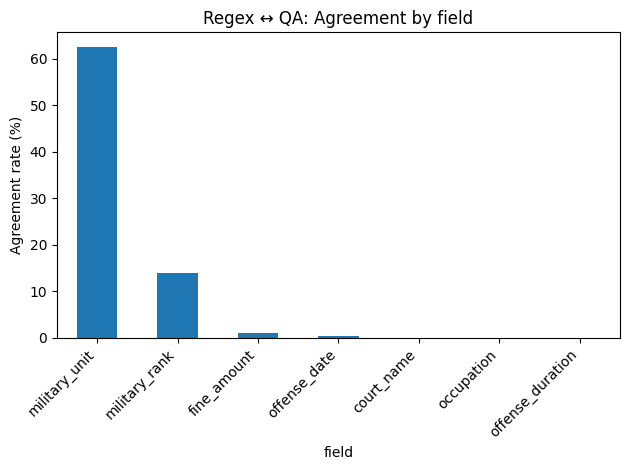

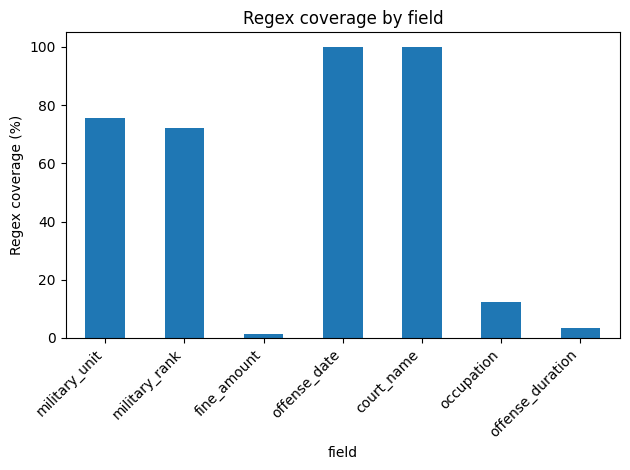

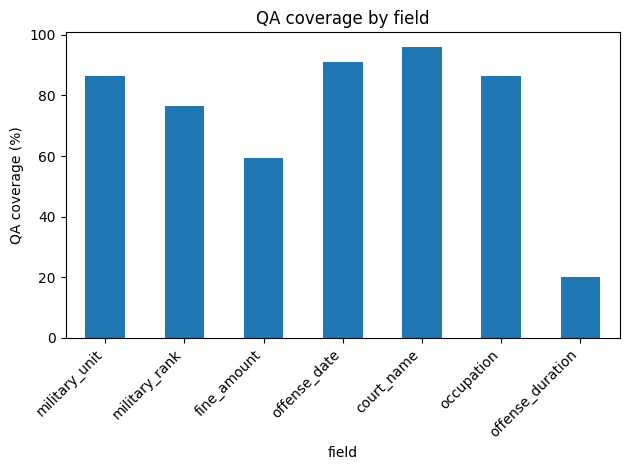

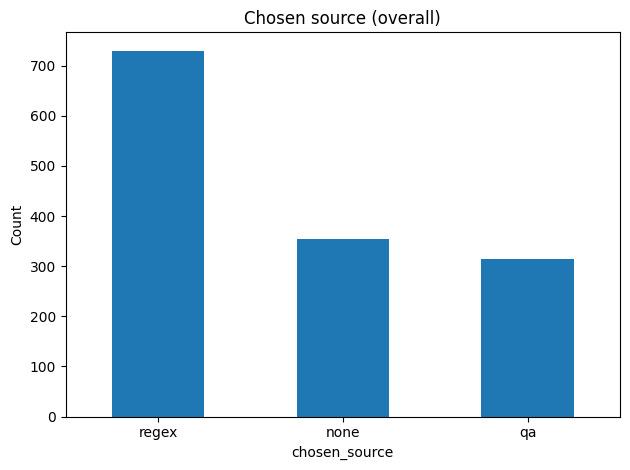

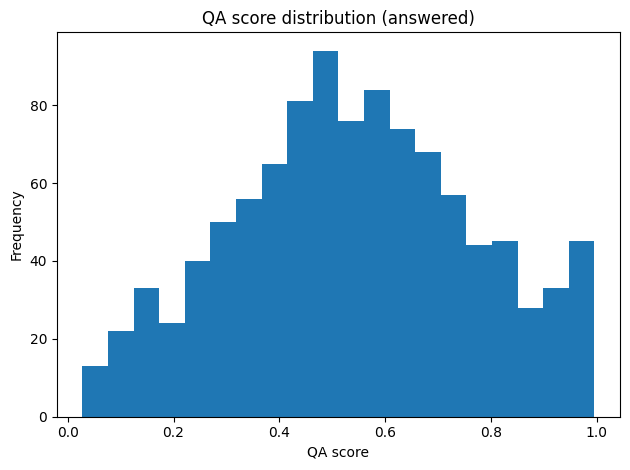

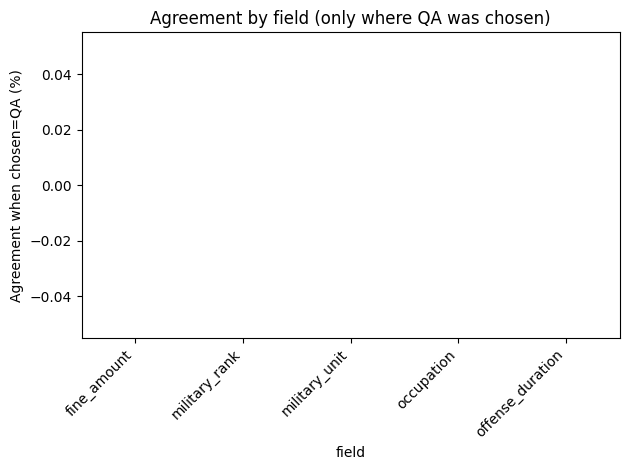

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==== config ====
CSV_PATH = "cross_ref_results.csv"   # change if needed

# ==== load & clean ====
df = pd.read_csv(CSV_PATH)

# normalize booleans/empties
df["agree"] = (
    df["agree"].astype(str).str.lower().isin(["true", "1", "yes"])
)
df["has_regex"] = df["regex_answer"].astype(str).str.strip().replace({"nan": ""}) != ""
df["has_qa"] = df["qa_answer"].astype(str).str.strip().replace({"nan": ""}) != ""
df["qa_score"] = pd.to_numeric(df.get("qa_score", np.nan), errors="coerce")
df["chosen_source"] = df.get("chosen_source", "none").fillna("none")

# ==== summary table (printed) ====
summary = (
    df.groupby("field")
      .agg(
          total=("field", "size"),
          agree_rate=("agree", "mean"),
          regex_cov=("has_regex", "mean"),
          qa_cov=("has_qa", "mean"),
          avg_qa_score=("qa_score", "mean"),
      )
      .sort_values("agree_rate", ascending=False)
)
print("\n=== SUMMARY BY FIELD ===")
print((summary * pd.Series({"agree_rate":100, "regex_cov":100, "qa_cov":100, "total":1, "avg_qa_score":1}))
      .round({"agree_rate":1, "regex_cov":1, "qa_cov":1, "avg_qa_score":3})
)

# ---- 1) Agreement rate by field ----
plt.figure()
(summary["agree_rate"] * 100).plot(kind="bar")
plt.ylabel("Agreement rate (%)")
plt.title("Regex ↔ QA: Agreement by field")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot_agreement_by_field.png", dpi=150)
plt.show()

# ---- 2) Regex coverage by field ----
plt.figure()
(summary["regex_cov"] * 100).plot(kind="bar")
plt.ylabel("Regex coverage (%)")
plt.title("Regex coverage by field")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot_regex_coverage_by_field.png", dpi=150)
plt.show()

# ---- 3) QA coverage by field ----
plt.figure()
(summary["qa_cov"] * 100).plot(kind="bar")
plt.ylabel("QA coverage (%)")
plt.title("QA coverage by field")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot_qa_coverage_by_field.png", dpi=150)
plt.show()

# ---- 4) Chosen source distribution (overall) ----
plt.figure()
df["chosen_source"].value_counts(dropna=False).sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Count")
plt.title("Chosen source (overall)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_chosen_source_overall.png", dpi=150)
plt.show()

# ---- 5) QA score distribution (where QA returned something) ----
plt.figure()
scores = df.loc[df["has_qa"] & df["qa_score"].notna(), "qa_score"]
if not scores.empty:
    plt.hist(scores, bins=20)
    plt.xlabel("QA score")
    plt.ylabel("Frequency")
    plt.title("QA score distribution (answered)")
    plt.tight_layout()
    plt.savefig("plot_qa_score_hist.png", dpi=150)
    plt.show()
else:
    print("No QA scores to plot.")

# ---- 6) Optional: agreement rate by field for chosen_source == 'qa' only ----
subset = df[df["chosen_source"] == "qa"]
if not subset.empty:
    agr = subset.groupby("field")["agree"].mean().sort_values(ascending=False) * 100
    plt.figure()
    agr.plot(kind="bar")
    plt.ylabel("Agreement when chosen=QA (%)")
    plt.title("Agreement by field (only where QA was chosen)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("plot_agreement_when_qa_chosen.png", dpi=150)
    plt.show()


In [10]:
df[df['agree'] == True]

,filename,field,question,regex_answer,qa_answer,qa_score,agree,chosen_answer,chosen_source,service_type,current_charges,null_file,has_regex,has_qa
15,101219332.html,military_unit,Яка військова частина розглядається у справі?,Військової частини НОМЕР_1,Військової частини НОМЕР_1,0.671808,True,Військової частини НОМЕР_1,regex,Contract,NaN,NaN,True,True
29,108781917.html,military_unit,Яка військова частина розглядається у справі?,військової частини НОМЕР_1,НОМЕР_1,0.823814,True,військової частини НОМЕР_1,regex,Mobilisation,NaN,NaN,True,True
43,105590744.html,military_unit,Яка військова частина розглядається у справі?,військової частини НОМЕР_3,НОМЕР_3,0.491804,True,військової частини НОМЕР_3,regex,NaN,NaN,NaN,True,True
45,105590744.html,military_rank,Яке звання військовослужбовця?,старший сержант,старший сержант,0.673650,True,старший сержант,regex,NaN,NaN,NaN,True,True
50,102604434.html,military_unit,Яка військова частина розглядається у справі?,військової частини НОМЕР_1,НОМЕР_1,0.476498,True,військової частини НОМЕР_1,regex,Contract,NaN,NaN,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1352,104595955.html,military_unit,Яка військова частина розглядається у справі?,Військової частини НОМЕР_1,НОМЕР_1,0.461080,True,Військової частини НОМЕР_1,regex,NaN,NaN,NaN,True,True
1366,106270060.html,military_unit,Яка військова частина розглядається у справі?,військової частини НОМЕР_1,НОМЕР_1,0.336203,True,військової частини НОМЕР_1,regex,Mobilisation,NaN,NaN,True,True
1373,110597162.html,military_unit,Яка військова частина розглядається у справі?,військової частини НОМЕР_1,НОМЕР_1,0.582272,True,військової частини НОМЕР_1,regex,NaN,NaN,NaN,True,True
1380,123951953.html,military_unit,Яка військова частина розглядається у справі?,військової частини НОМЕР_1,НОМЕР_1,0.600445,True,військової частини НОМЕР_1,regex,Mobilisation,NaN,NaN,True,True
